In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
from SharedX import ShareXaxis
from UniversalColor import UniversalColor
from legend_shadow import legend_shadow
from scipy.io import readsav
import spiceypy as spice

import JupiterMag as jm
import Leadangle_wave as LeadA

from Leadangle_fit_JunoUVS import Obsresults
from Leadangle_fit_JunoUVS import viewingangle
from Leadangle_fit_JunoUVS import calc_eqlead
from Leadangle_fit_JunoUVS import local_time_moon
from Leadangle_fit_JunoUVS import moonS3wlon_arr

UC = UniversalColor()
UC.set_palette()

F = ShareXaxis()
F.fontsize = 23
F.fontname = 'Liberation Sans Narrow'
F.set_default()

Importing Library
done


In [2]:
spice.furnsh('kernel/cassMetaK.txt')
radii = spice.bodvrd("JUPITER", "RADII", 3)[1]
a = radii[0]
c = radii[2]
f = (a - c) / a

In [3]:
# Input about Juno observation
TARGET_MOON = 'Ganymede'
TARGET_FP = ['MAW', 'TEB']
TARGET_HEM = 'both'
PJ_LIST = [1, 3]+np.arange(4, 68+1, 1).tolist()

In [4]:
# %% Constants
MU0 = 1.26E-6            # 真空中の透磁率
AMU2KG = 1.66E-27        # 原子質量をkgに変換するファクタ [kg]
RJ = 71492E+3            # JUPITER RADIUS [m]
MJ = 1.90E+27            # JUPITER MASS [kg]
C = 2.99792E+8           # LIGHT SPEED [m/s]
G = 6.67E-11             # 万有引力定数  [m^3 kg^-1 s^-2]

Psyn_io = (12.89)*3600      # Moon's synodic period [sec]
Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

# Select moon synodic orbital period
if TARGET_MOON == 'Io':
    Psyn = Psyn_io
    r_moon = 5.9*RJ
elif TARGET_MOON == 'Europa':
    Psyn = Psyn_eu
    r_moon = 9.4*RJ
elif TARGET_MOON == 'Ganymede':
    Psyn = Psyn_ga
    r_moon = 15.0*RJ

In [5]:
# Select moon synodic orbital period
if len(PJ_LIST) > 1:
    if TARGET_MOON == 'Io':
        Psyn = Psyn_io
        PJ_LIST.pop(54-2)
        PJ_LIST.pop(55-3)
        PJ_LIST.pop(56-4)
        PJ_LIST.pop(57-5)
        PJ_LIST.pop(61-6)
        PJ_LIST.pop(63-7)
        PJ_LIST.pop(64-8)
        PJ_LIST.pop(65-9)
        PJ_LIST.pop(67-10)
        r_moon = 5.9*RJ
    elif TARGET_MOON == 'Europa':
        Psyn = Psyn_eu
        PJ_LIST.pop(24-2)
        PJ_LIST.pop(43-3)
        PJ_LIST.pop(47-4)
        PJ_LIST.pop(49-5)
        PJ_LIST.pop(50-6)
        PJ_LIST.pop(51-7)
        PJ_LIST.pop(53-8)
        PJ_LIST.pop(55-9)
        PJ_LIST.pop(56-10)
        PJ_LIST.pop(60-11)
        PJ_LIST.pop(61-12)
        PJ_LIST.pop(63-13)
        PJ_LIST.pop(64-14)
        PJ_LIST.pop(65-15)
        PJ_LIST.pop(66-16)
        PJ_LIST.pop(67-17)
        PJ_LIST.pop(68-18)
        r_moon = 9.4*RJ
    elif TARGET_MOON == 'Ganymede':
        Psyn = Psyn_ga
        PJ_LIST.pop(24-2)
        PJ_LIST.pop(31-3)
        PJ_LIST.pop(39-4)
        PJ_LIST.pop(43-5)
        PJ_LIST.pop(44-6)
        PJ_LIST.pop(45-7)
        PJ_LIST.pop(51-8)
        PJ_LIST.pop(52-9)
        PJ_LIST.pop(53-10)
        PJ_LIST.pop(54-11)
        PJ_LIST.pop(55-12)
        PJ_LIST.pop(56-13)
        PJ_LIST.pop(61-14)
        PJ_LIST.pop(62-15)
        PJ_LIST.pop(63-16)
        PJ_LIST.pop(64-17)
        PJ_LIST.pop(65-18)
        PJ_LIST.pop(66-19)
        PJ_LIST.pop(67-20)
        PJ_LIST.pop(68-21)
        r_moon = 15.0*RJ

    print(PJ_LIST)

[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 46, 47, 48, 49, 50, 57, 58, 59, 60]


In [6]:
# Data
wlon_fp, err_wlon_fp, lat_fp, err_lat_fp, moon_S3wlon, et_fp, hem_fp, pj_fp = Obsresults(
    PJ_LIST, TARGET_MOON, TARGET_FP, TARGET_HEM=TARGET_HEM, FLIP=False
)

eqlead_fp, eqlead_fp_0, eqlead_fp_1, wlon_fp_eq = calc_eqlead(wlon_fp,
                                                              err_wlon_fp,
                                                              lat_fp,
                                                              err_lat_fp,
                                                              hem_fp,
                                                              moon_S3wlon,
                                                              TARGET_MOON)

# Emission angle
view_angle = np.zeros(3)
for i in PJ_LIST:
    for j in TARGET_FP:
        view_angle1 = viewingangle(PJnum=i,
                                   target_moon=TARGET_MOON,
                                   target_fp=j,
                                   target_hem=TARGET_HEM,
                                   FLIP=False)
        view_angle = np.append(view_angle, view_angle1)

# 余計な部分を削除
view_angle = view_angle[3:]

# Emission angleで制限
view_idx = np.where((view_angle <= 30.0))

wlon_fp = wlon_fp[view_idx]
err_wlon_fp = err_wlon_fp[view_idx]
lat_fp = lat_fp[view_idx]
err_lat_fp = err_lat_fp[view_idx]
moon_S3wlon = moon_S3wlon[view_idx]
et_fp = et_fp[view_idx]
hem_fp = hem_fp[view_idx]
pj_fp = pj_fp[view_idx]
eqlead_fp = eqlead_fp[view_idx]
view_angle = view_angle[view_idx]

print(wlon_fp.shape)

(500,)


In [7]:
# %% Data from Connerney+2020: PJ index
con20_pj_idx = np.array([1, 3, 4, 5, 6,
                         7, 8, 9, 10, 11,
                         12, 13, 14, 15, 16,
                         17, 18, 19, 20, 21,
                         22, 23, 24], dtype=int)


# %% Data from Connerney+2020: Current constant [nT]
con20_mu_i_tot = np.array([150.1, 137.8, 127.2, 129.1, 130.1,
                           142.3, 140.1, 143.8, 137.0, 141.4,
                           124.2, 148.9, 145.3, 144.8, 149.9,
                           132.1, 133.5, 152.9, 138.5, 138.8,
                           156.1, 141.4, 146.3])


# %% Data from Connerney+2020: Radial current constant [MA]
con20_mu_i_rho = np.array([35.2, 14.6, 7.7, 11.5, 20.8,
                           20.2, 12.2, 21.1, 20.9, 10.7,
                           26.26, 16.4, 12.0, 19.6, 12.0,
                           13.6, 20.0, 12.8, 16.0, 17.3,
                           9.9, 16.1, 10.3])

In [ ]:
wlon_modelfp = np.zeros(3)
lat_modelfp = np.zeros(3)

for k in range(con20_pj_idx.size):
    jm.Internal.Config(Model='jrm33', Degree=13,
                       CartesianIn=True, CartesianOut=True)
    jm.Con2020.Config(mu_i=con20_mu_i_tot[k], equation_type='analytic')

    pj_select_idx = np.where(pj_fp == con20_pj_idx[k])
    moon_S3wlon_select = moon_S3wlon[pj_select_idx]
    eqlead_fp_select = eqlead_fp[pj_select_idx]
    hem_fp_select = hem_fp[pj_select_idx]
    view_angle_select = view_angle[pj_select_idx]    # [deg]
    wlon_fp_select = wlon_fp[pj_select_idx]          # [deg]
    lat_fp_select = lat_fp[pj_select_idx]            # [deg]
    err_lat_fp_select = err_lat_fp[pj_select_idx]    # [deg]
    et_fp_select = et_fp[pj_select_idx]

    wlon_modelfp_k = np.zeros(moon_S3wlon_select.size)
    lat_modelfp_k = np.zeros(moon_S3wlon_select.size)

    for j in range(pj_select_idx[0].size):
        # Orbital distance at the PJ time
        _, _, z0_moon_obs, r_moon_obs, _, _, _ = moonS3wlon_arr(np.array([et_fp_select[j]]),
                                                                TARGET_MOON)

        # Manual trace
        phi0 = math.radians(360.0-(moon_S3wlon_select[j]-eqlead_fp_select[j]))
        x0 = r_moon_obs[0]*math.cos(phi0)
        y0 = r_moon_obs[0]*math.sin(phi0)
        z0 = z0_moon_obs[0]/RJ

        Niter = int(600000)

        ds = 50000.0     # [m]

        if hem_fp_select[j] < 0:
            ns = -1
        else:
            ns = 1

        x, y, z = x0/RJ, y0/RJ, z0/RJ
        for i in range(Niter):
            # Community codes
            Bx0, By0, Bz0 = jm.Internal.Field(x, y, z)  # [nT]
            Bx1, By1, Bz1 = jm.Con2020.Field(x, y, z)   # [nT]
            Bx = (Bx0+Bx1)*1E-9     # [T]
            By = (By0+By1)*1E-9     # [T]
            Bz = (Bz0+Bz1)*1E-9     # [T]

            B0 = math.sqrt(Bx[0]**2+By[0]**2+Bz[0]**2)      # [T]

            # 座標更新 (x, y, z)
            x += (ds*Bx[0]/B0)*ns/RJ
            y += (ds*By[0]/B0)*ns/RJ
            z += (ds*Bz[0]/B0)*ns/RJ

            # 座標更新 (r, theta, phi)
            rs = math.sqrt(x**2 + y**2 + z**2)      # [RJ]
            theta = math.acos(z/rs)
            phi = math.atan2(y, x)

            # 高度h [km]の座標テーブルを参照
            if (i > 3500) and (rs < (1.0*RJ+2500.0E+3)/RJ):
                ds = 3000.0     # 線要素長を短く(5 kmより小さくする) [m]

                # Jovigraphic (gr)
                lon_gr, lat_gr, alt_gr = spice.recpgr("JUPITER",
                                                      np.array([x*RJ/1000.0,
                                                                y*RJ/1000.0,
                                                                z*RJ/1000.0]),
                                                      a,
                                                      f)
                if abs(alt_gr-900.0)*1000.0 <= 0.5*ds:
                    wlon_modelfp_k[j] = np.mod(360.0-math.degrees(phi), 360.0)
                    lat_modelfp_k[j] = 90.0-math.degrees(theta)
                    print(hem_fp_select[j], lat_modelfp_k[j], alt_gr)
                    break
    wlon_modelfp = np.append(wlon_modelfp, wlon_modelfp_k)
    lat_modelfp = np.append(lat_modelfp, lat_modelfp_k)

wlon_modelfp = wlon_modelfp[3:]
lat_modelfp = lat_modelfp[3:]

1 -77.0321874801474 898.8463286905941
1 -75.67077107205057 899.9633308683093
1 -75.55091993548837 899.8929991157736
1 -75.45968828861248 899.7204381198172
1 -75.15767609159286 900.8634885153817
-1 54.038380027190954 899.041697176727
-1 54.012124019434246 898.9978887478632
-1 54.00549983474529 901.2514189298565
-1 53.89086849605734 899.706847264787
-1 53.86087636315236 900.4453950113699
-1 53.84767025176265 898.967013502032
-1 53.81844330200621 898.8234087323348
1 -80.01331978092205 899.1125048655932
1 -79.99609667618824 900.1115109348609
1 -79.9219496748047 900.0846669143154
1 -79.92179587435433 901.2796224601391
1 -79.75612007284329 900.9123695142486
101 -79.02802506908742 899.3351008442329
101 -78.81564394385055 898.8414173328504
101 -78.68913105708481 900.3184991229504
101 -78.65482767704063 899.2953630324276
101 -78.51134935445069 899.1678332525897
101 -78.43668718187365 899.5737337029523
101 -78.3618749597511 901.0140290622377


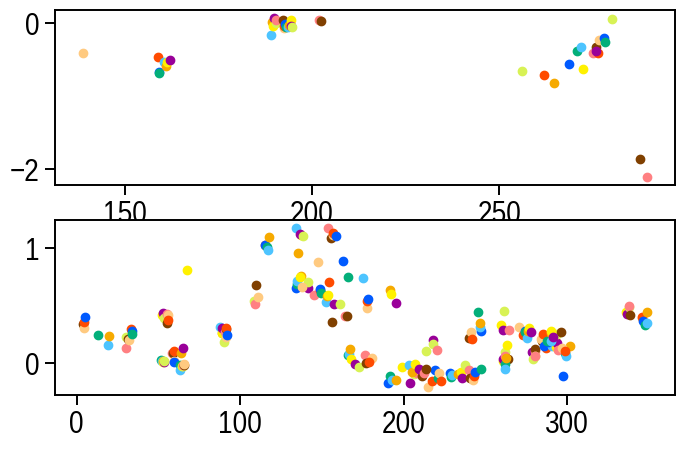

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))
for k in range(con20_pj_idx.size):
    pj_select_idx = np.where(pj_fp == con20_pj_idx[k])
    moon_S3wlon_select = moon_S3wlon[pj_select_idx]
    hem_fp_select = hem_fp[pj_select_idx]
    view_angle_select = view_angle[pj_select_idx]    # [deg]
    wlon_fp_select = wlon_fp[pj_select_idx]          # [deg]
    lat_fp_select = lat_fp[pj_select_idx]            # [deg]
    err_lat_fp_select = err_lat_fp[pj_select_idx]    # [deg]
    et_fp_select = et_fp[pj_select_idx]

    wlon_modelfp_select = wlon_modelfp[pj_select_idx]
    lat_modelfp_select = lat_modelfp[pj_select_idx]

    for j in range(moon_S3wlon_select.size):
        if hem_fp_select[j] < 0:
            ax_idx = 0
            # print(lat_modelfp_select[j])
        else:
            ax_idx = 1
        ax[ax_idx].scatter(wlon_fp_select[j],
                           lat_modelfp_select[j]-lat_fp_select[j])

plt.show()

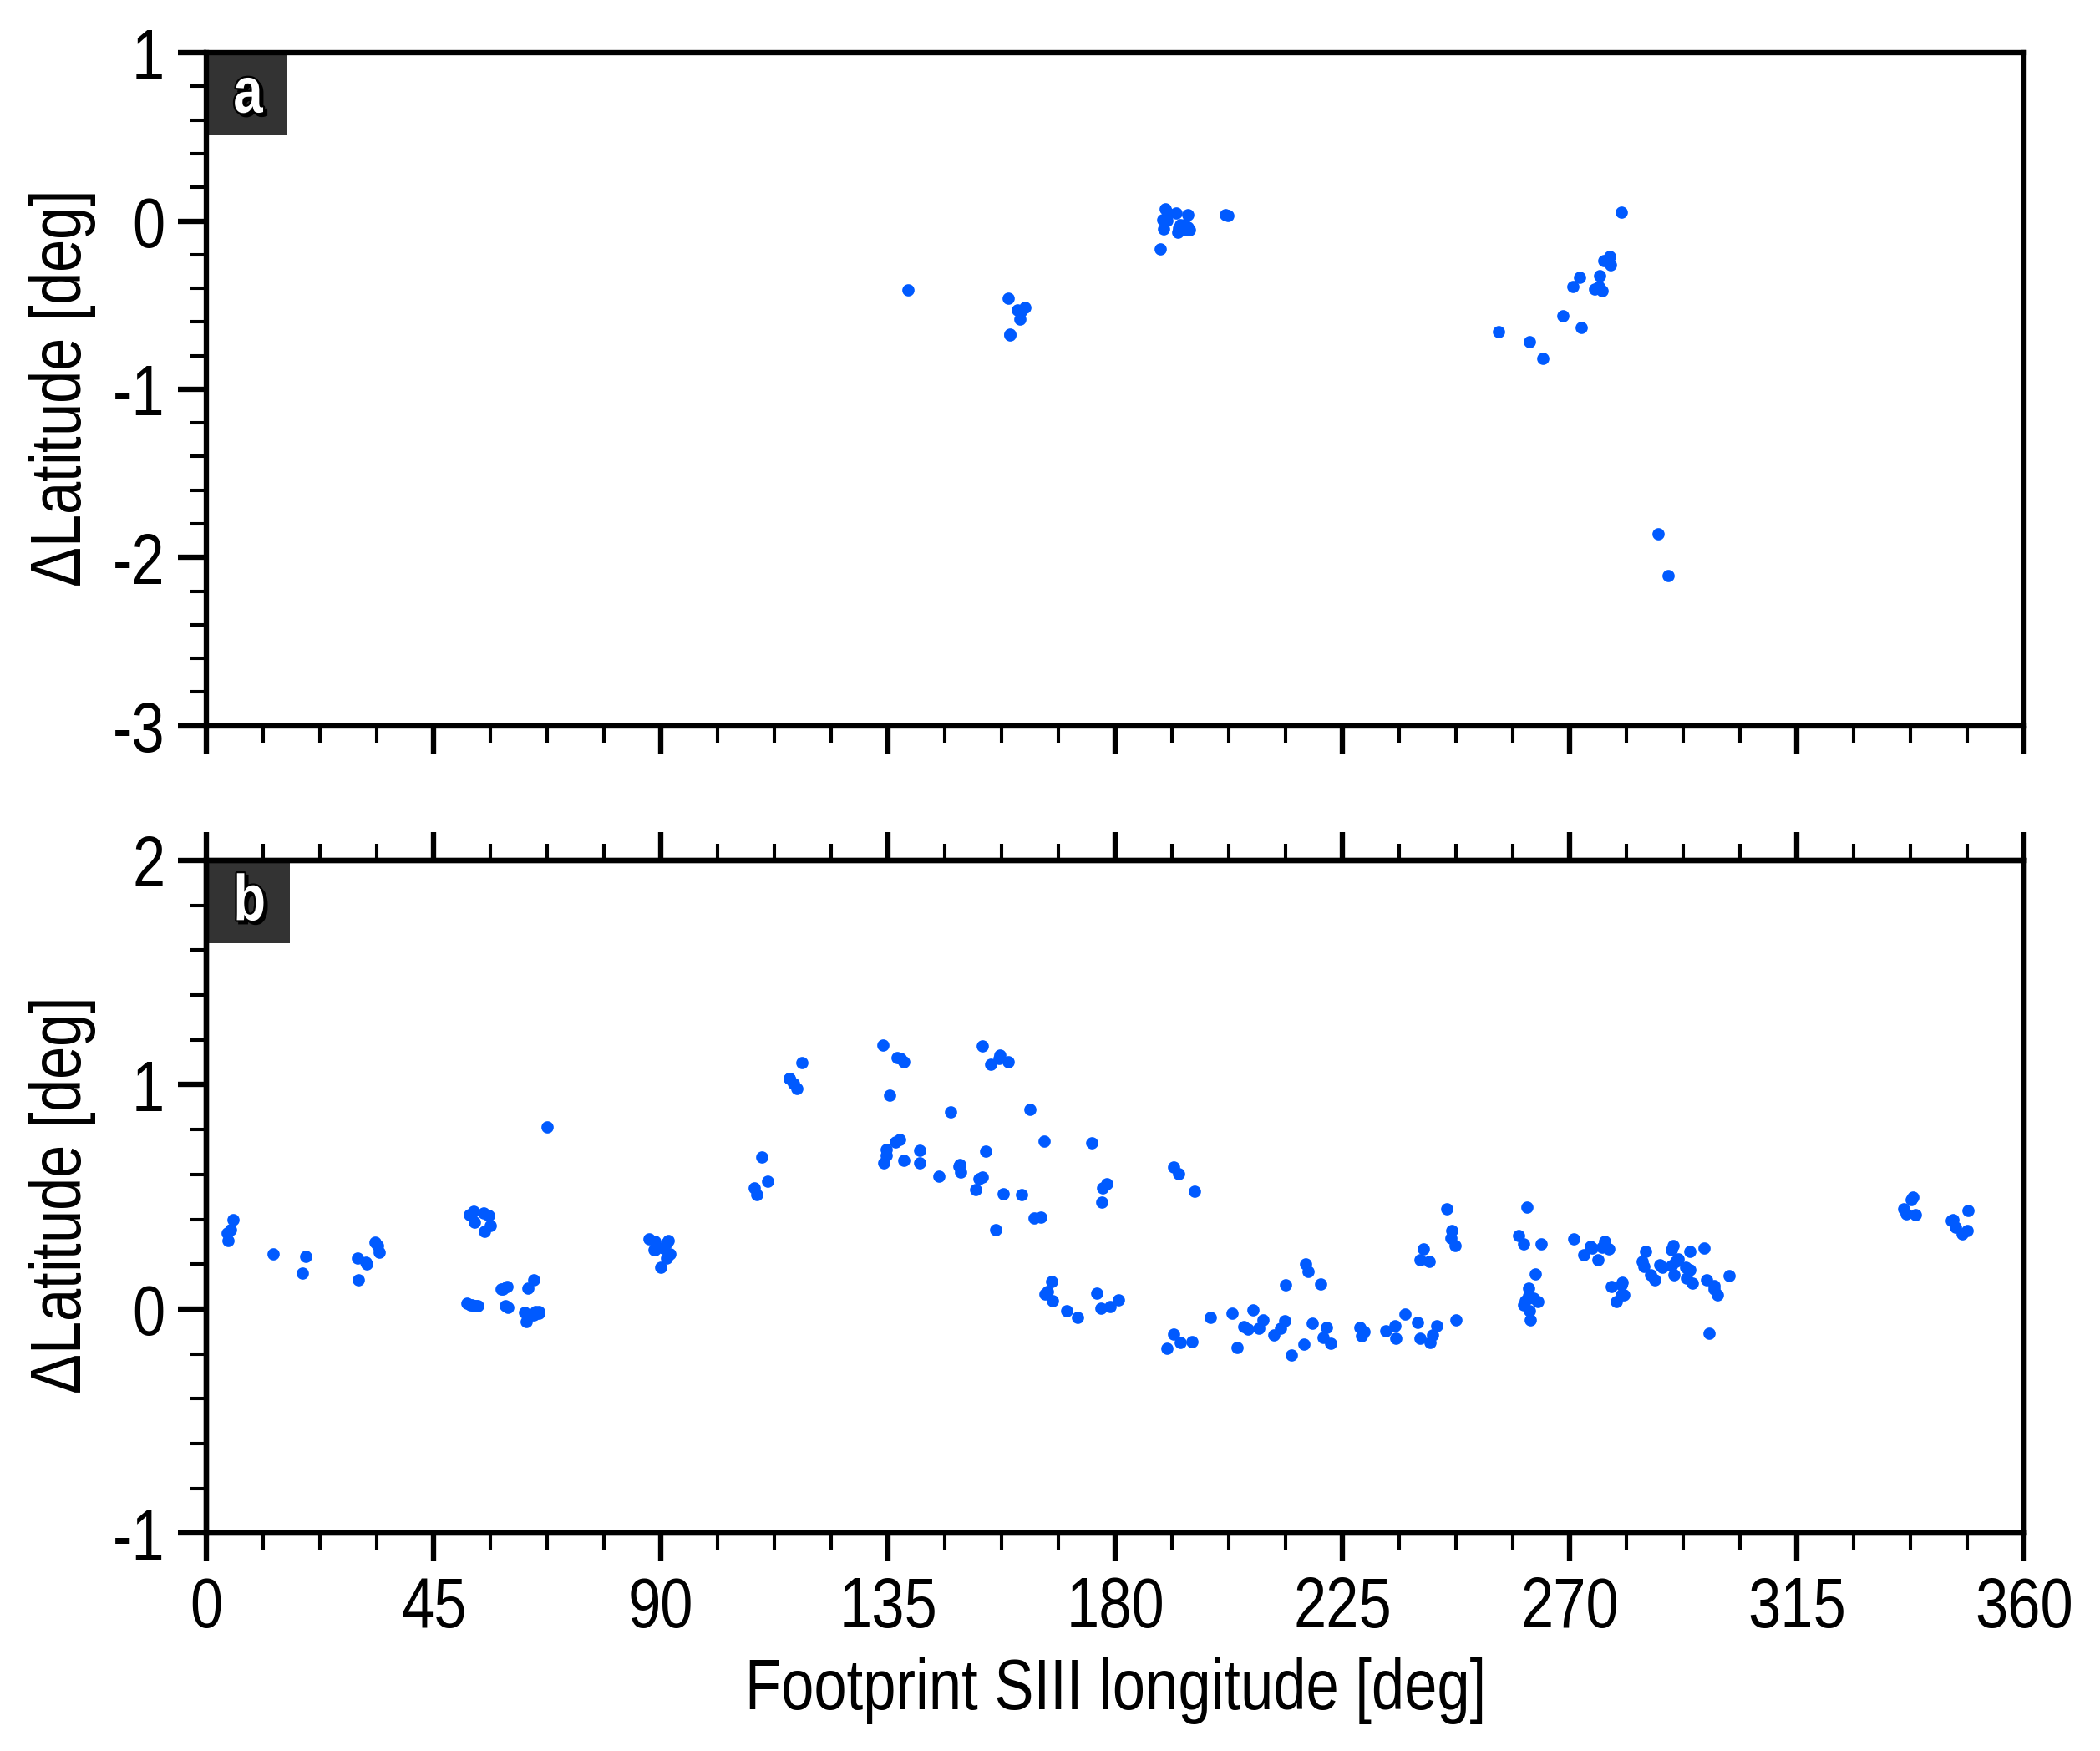

In [ ]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Footprint SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
F.set_yaxis(ax_idx=0,
            label=r'$\Delta$Latitude [deg]',
            min=-3, max=1,
            ticks=np.linspace(-3, 1, 5),
            ticklabels=np.linspace(-3, 1, 5, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'$\Delta$Latitude [deg]',
            min=-1, max=2,
            ticks=np.linspace(-1, 2, 4),
            ticklabels=np.linspace(-1, 2, 4, dtype=int),
            minor_num=5)

for k in range(con20_pj_idx.size):
    pj_select_idx = np.where(pj_fp == con20_pj_idx[k])
    moon_S3wlon_select = moon_S3wlon[pj_select_idx]
    hem_fp_select = hem_fp[pj_select_idx]
    view_angle_select = view_angle[pj_select_idx]    # [deg]
    wlon_fp_select = wlon_fp[pj_select_idx]          # [deg]
    lat_fp_select = lat_fp[pj_select_idx]            # [deg]
    err_lat_fp_select = err_lat_fp[pj_select_idx]    # [deg]
    et_fp_select = et_fp[pj_select_idx]

    wlon_modelfp_select = wlon_modelfp[pj_select_idx]
    lat_modelfp_select = lat_modelfp[pj_select_idx]

    for j in range(moon_S3wlon_select.size):
        if hem_fp_select[j] < 0:
            ax_idx = 0
            # print(lat_modelfp_select[j])
        else:
            ax_idx = 1
        F.ax[ax_idx].scatter(wlon_fp_select[j], lat_modelfp_select[j]-lat_fp_select[j],
                             s=5.0, color=UC.blue)
        F.ax[ax_idx].errorbar(x=wlon_fp_select[j],
                              y=lat_modelfp_select[j]-lat_fp_select[j],
                              yerr=et_fp_select[j],
                              elinewidth=1.1, linewidth=0., markersize=0.,
                              capsize=2.0, capthick=1.1,
                              color=UC.blue)

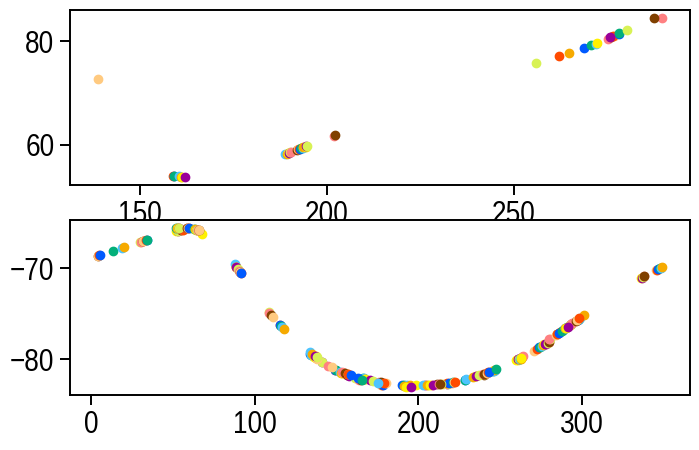

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))
for k in range(con20_pj_idx.size):
    pj_select_idx = np.where(pj_fp == con20_pj_idx[k])
    moon_S3wlon_select = moon_S3wlon[pj_select_idx]
    hem_fp_select = hem_fp[pj_select_idx]
    view_angle_select = view_angle[pj_select_idx]
    wlon_fp_select = wlon_fp[pj_select_idx]     # [deg]
    lat_fp_select = lat_fp[pj_select_idx]       # [deg]
    et_fp_select = et_fp[pj_select_idx]

    wlon_modelfp_select = wlon_modelfp[pj_select_idx]
    lat_modelfp_select = lat_modelfp[pj_select_idx]

    for j in range(moon_S3wlon_select.size):
        if hem_fp_select[j] < 0:
            ax_idx = 0
            # print(lat_modelfp_select[j])
        else:
            ax_idx = 1
        # ax[ax_idx].scatter(moon_S3wlon_select[j], lat_fp_select[j])
        ax[ax_idx].scatter(wlon_fp_select[j], lat_modelfp_select[j])

plt.show()

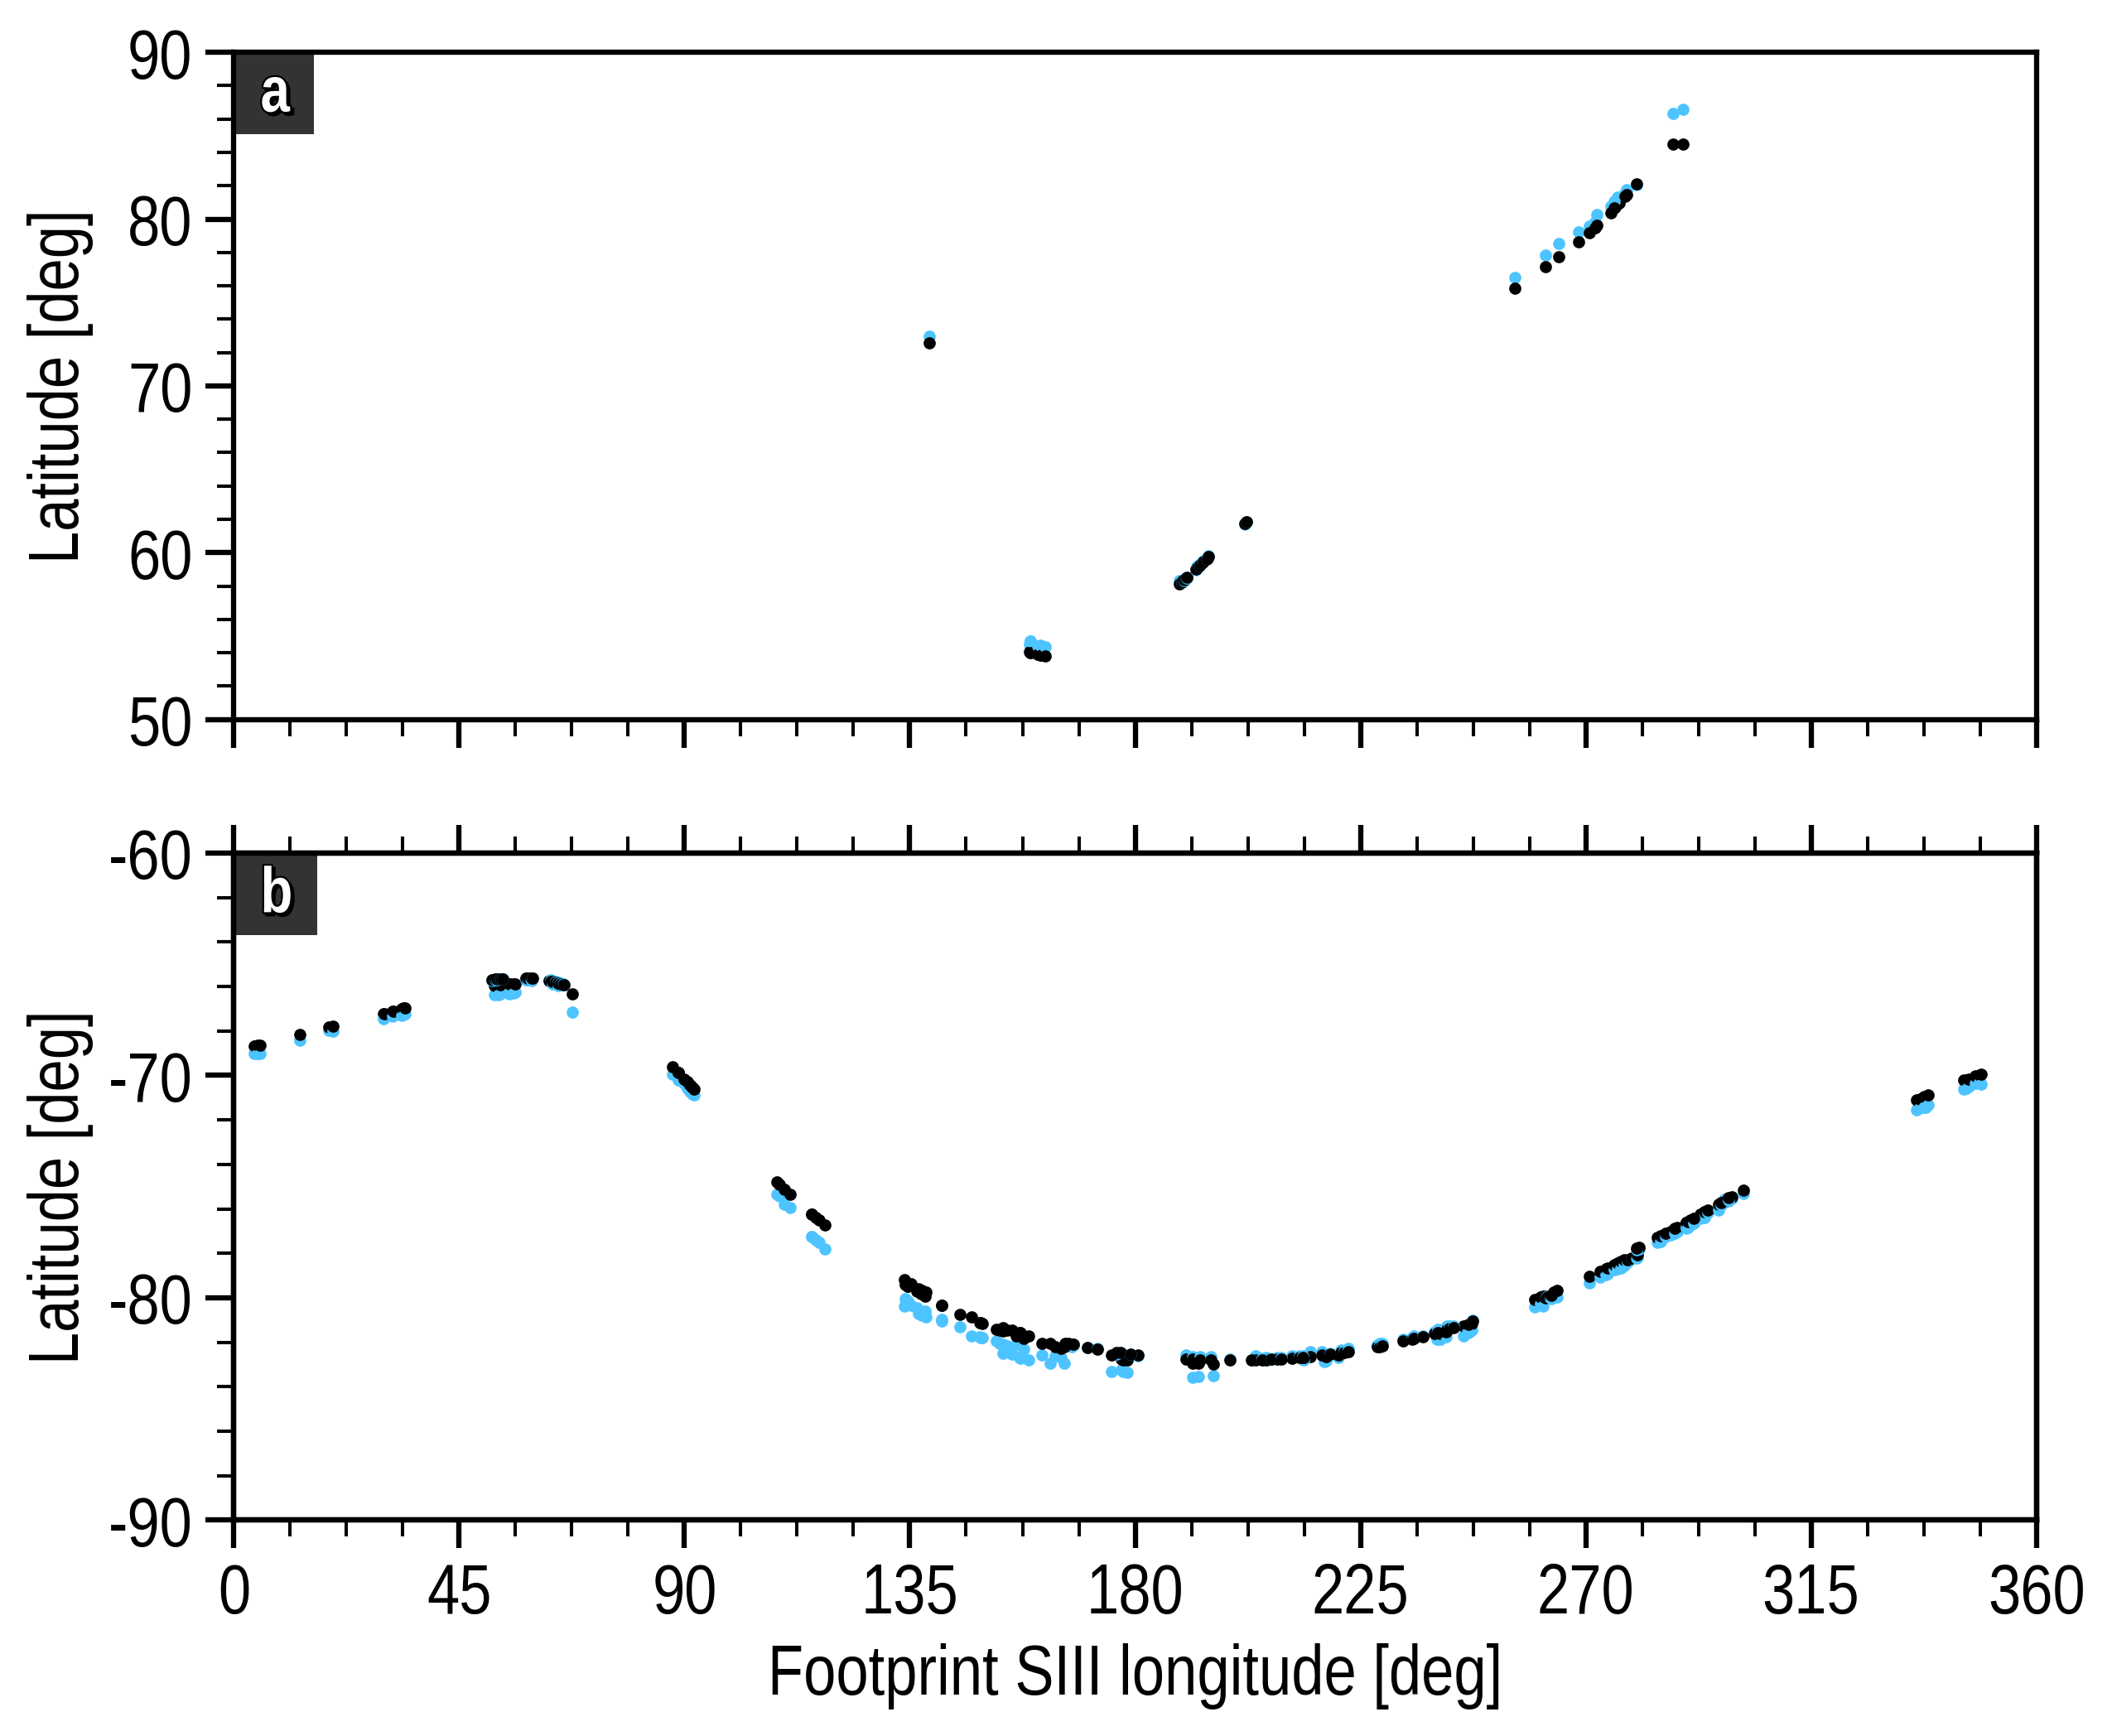

In [ ]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=2, figsize=(8, 6.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = np.arange(0, 360+1, 45)
xticklabels = np.arange(0, 360+1, 45, dtype=int)

F.set_xaxis(label=r'Footprint SIII longitude [deg]',
            min=0.0, max=360.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
F.set_yaxis(ax_idx=0,
            label=r'Latitude [deg]',
            min=50, max=90,
            ticks=np.linspace(50, 90, 5),
            ticklabels=np.linspace(50, 90, 5, dtype=int),
            minor_num=5)
F.set_yaxis(ax_idx=1,
            label=r'Latitude [deg]',
            min=-90, max=-60,
            ticks=np.linspace(-90, -60, 4),
            ticklabels=np.linspace(-90, -60, 4, dtype=int),
            minor_num=5)

for k in range(con20_pj_idx.size):
    pj_select_idx = np.where(pj_fp == con20_pj_idx[k])
    moon_S3wlon_select = moon_S3wlon[pj_select_idx]
    hem_fp_select = hem_fp[pj_select_idx]
    view_angle_select = view_angle[pj_select_idx]
    wlon_fp_select = wlon_fp[pj_select_idx]     # [deg]
    lat_fp_select = lat_fp[pj_select_idx]       # [deg]
    et_fp_select = et_fp[pj_select_idx]

    wlon_modelfp_select = wlon_modelfp[pj_select_idx]
    lat_modelfp_select = lat_modelfp[pj_select_idx]

    for j in range(moon_S3wlon_select.size):
        if hem_fp_select[j] < 0:
            ax_idx = 0
            # print(lat_modelfp_select[j])
        else:
            ax_idx = 1
        F.ax[ax_idx].scatter(wlon_fp_select[j], lat_fp_select[j],
                             s=5.0, color=UC.lightblue)
        F.ax[ax_idx].scatter(wlon_fp_select[j], lat_modelfp_select[j],
                             s=5.0, color='k')

# FootpathとFootprint (obs)の距離を測る

In [ ]:
wlon_modelfp = np.zeros(3)
lat_modelfp = np.zeros(3)

for k in range(con20_pj_idx.size):
    jm.Internal.Config(Model='jrm33', Degree=13,
                       CartesianIn=True, CartesianOut=True)
    jm.Con2020.Config(mu_i=con20_mu_i_tot[k], equation_type='analytic')

    pj_select_idx = np.where(pj_fp == con20_pj_idx[k])
    moon_S3wlon_select = moon_S3wlon[pj_select_idx]
    eqlead_fp_select = eqlead_fp[pj_select_idx]
    hem_fp_select = hem_fp[pj_select_idx]
    view_angle_select = view_angle[pj_select_idx]
    wlon_fp_select = wlon_fp[pj_select_idx]     # [deg]
    lat_fp_select = lat_fp[pj_select_idx]       # [deg]
    et_fp_select = et_fp[pj_select_idx]

    wlon_modelfp_k = np.zeros(moon_S3wlon_select.size)
    lat_modelfp_k = np.zeros(moon_S3wlon_select.size)

    for j in range(pj_select_idx[0].size):
        # Orbital distance at the PJ time
        _, _, _, r_moon_obs, _, _, _ = moonS3wlon_arr(np.array([et_fp_select[j]]),
                                                      TARGET_MOON)

        # Manual trace
        phi0 = math.radians(360.0-(moon_S3wlon_select[j]-eqlead_fp_select[j]))
        x0 = r_moon_obs[0]*math.cos(phi0)
        y0 = r_moon_obs[0]*math.sin(phi0)
        z0 = 0.0

        Niter = int(600000)

        ds = 50000.0     # [m]

        if hem_fp_select[j] < 0:
            ns = -1
        else:
            ns = 1

        x, y, z = x0/RJ, y0/RJ, z0/RJ
        for i in range(Niter):
            # Community codes
            Bx0, By0, Bz0 = jm.Internal.Field(x, y, z)  # [nT]
            Bx1, By1, Bz1 = jm.Con2020.Field(x, y, z)   # [nT]
            Bx = (Bx0+Bx1)*1E-9     # [T]
            By = (By0+By1)*1E-9     # [T]
            Bz = (Bz0+Bz1)*1E-9     # [T]

            B0 = math.sqrt(Bx[0]**2+By[0]**2+Bz[0]**2)      # [T]

            # 座標更新 (x, y, z)
            x += (ds*Bx[0]/B0)*ns/RJ
            y += (ds*By[0]/B0)*ns/RJ
            z += (ds*Bz[0]/B0)*ns/RJ

            # 座標更新 (r, theta, phi)
            rs = math.sqrt(x**2 + y**2 + z**2)      # [RJ]
            theta = math.acos(z/rs)
            phi = math.atan2(y, x)

            # 高度h [km]の座標テーブルを参照
            if (i > 3500) and (rs < (1.0*RJ+2500.0E+3)/RJ):
                ds = 3000.0     # 線要素長を短く(5 kmより小さくする) [m]

                # Jovigraphic (gr)
                lon_gr, lat_gr, alt_gr = spice.recpgr("JUPITER",
                                                      np.array([x*RJ/1000.0,
                                                                y*RJ/1000.0,
                                                                z*RJ/1000.0]),
                                                      a,
                                                      f)
                if abs(alt_gr-900.0)*1000.0 <= 0.5*ds:
                    wlon_modelfp_k[j] = np.mod(360.0-math.degrees(phi), 360.0)
                    lat_modelfp_k[j] = 90.0-math.degrees(theta)
                    print(hem_fp_select[j], lat_modelfp_k[j], alt_gr)
                    break
    wlon_modelfp = np.append(wlon_modelfp, wlon_modelfp_k)
    lat_modelfp = np.append(lat_modelfp, lat_modelfp_k)

wlon_modelfp = wlon_modelfp[3:]
lat_modelfp = lat_modelfp[3:]